# Student Dropout Early Intervention System — Exploratory Data Analysis

This notebook explores the strongest dropout risk factors in the UCI/Kaggle
*"Predict Students' Dropout and Academic Success"* dataset. Every figure is
also saved to `docs/figures/` for use in slides/screenshots.

Data loading and column detection reuse the same `src.utils` helpers as the
production pipeline, so this analysis is guaranteed to be looking at the
same data the model is trained on.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src import config
from src.utils import load_raw_csv, detect_target_column

sns.set_theme(style="whitegrid")
FIGURES_DIR = config.FIGURES_DIR
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = load_raw_csv(config.RAW_CSV_PATH)
target_col = detect_target_column(df)
print(f"Shape: {df.shape}, target column: '{target_col}'")
df[target_col].value_counts()

Shape: (4424, 35), target column: 'Target'


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

## 1. Target class distribution
Confirms the ~2.8x class imbalance flagged in the P1 data audit.

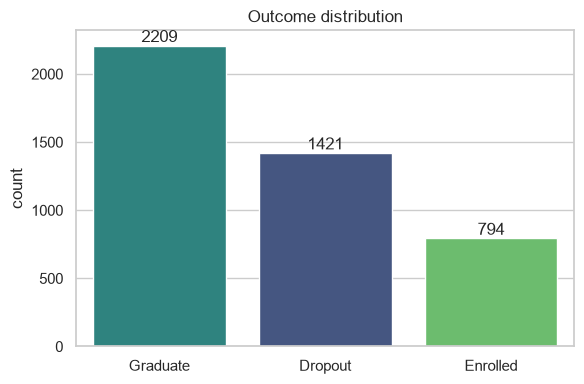

In [2]:
order = df[target_col].value_counts().index
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x=target_col, order=order, hue=target_col, palette="viridis", legend=False, ax=ax)
ax.set_title("Outcome distribution")
ax.set_xlabel("")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "target_distribution.png", dpi=150)
plt.show()

## 2. Curricular units approved (1st & 2nd semester) vs outcome
The single strongest signal in the dataset: students who fail to get units
approved in-program are overwhelmingly the ones who drop out.

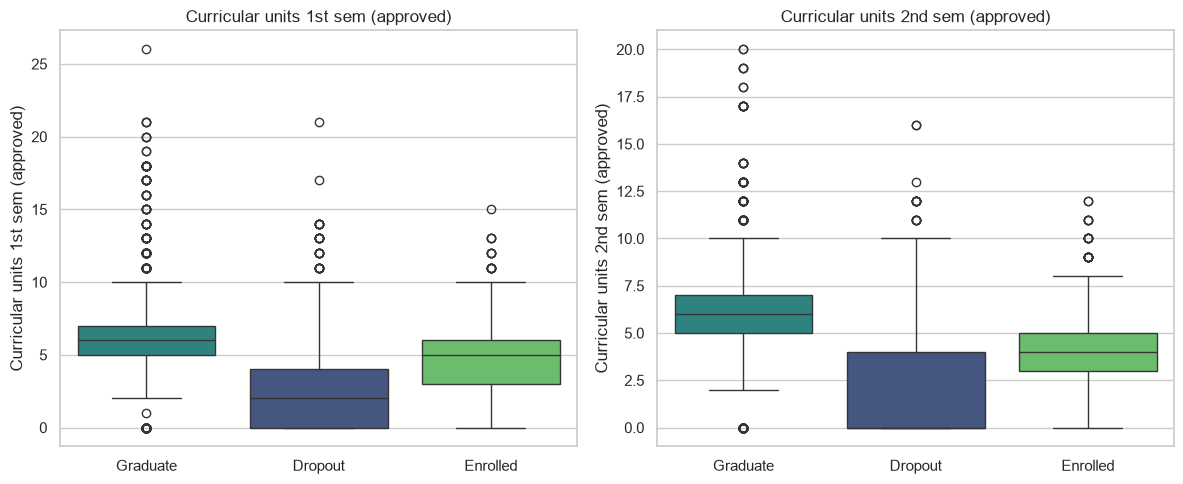

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, ["Curricular units 1st sem (approved)", "Curricular units 2nd sem (approved)"]):
    sns.boxplot(data=df, x=target_col, y=col, order=order, hue=target_col, palette="viridis", legend=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "approved_units_vs_outcome.png", dpi=150)
plt.show()

## 3. Semester grades vs outcome

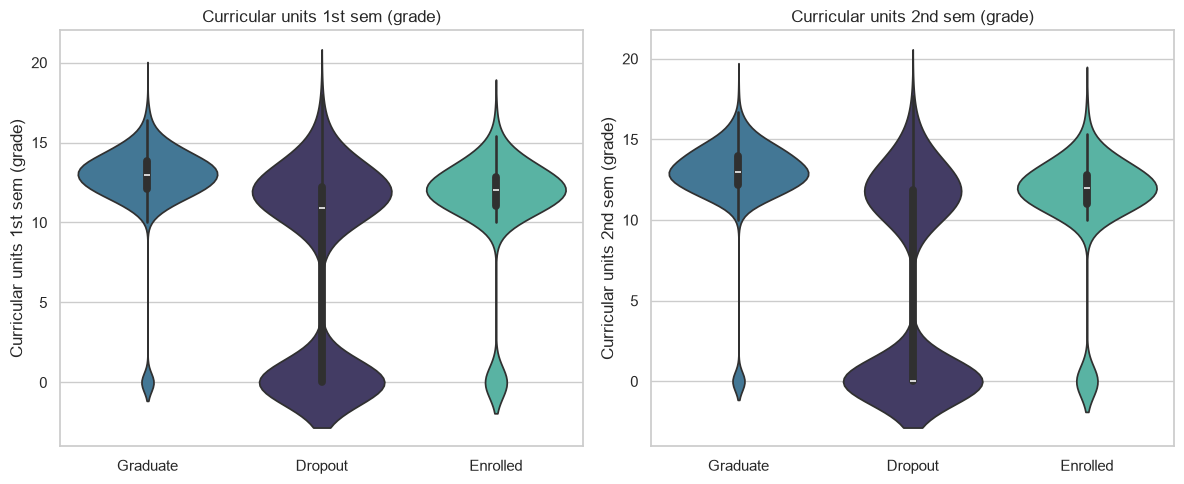

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, ["Curricular units 1st sem (grade)", "Curricular units 2nd sem (grade)"]):
    sns.violinplot(data=df, x=target_col, y=col, order=order, hue=target_col, palette="mako", legend=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "grades_vs_outcome.png", dpi=150)
plt.show()

## 4. Financial factors: tuition fees, debtor status, scholarship
Financial precarity is a strong, actionable dropout signal — actionable
because it maps directly to a financial-aid intervention, not just a
label.

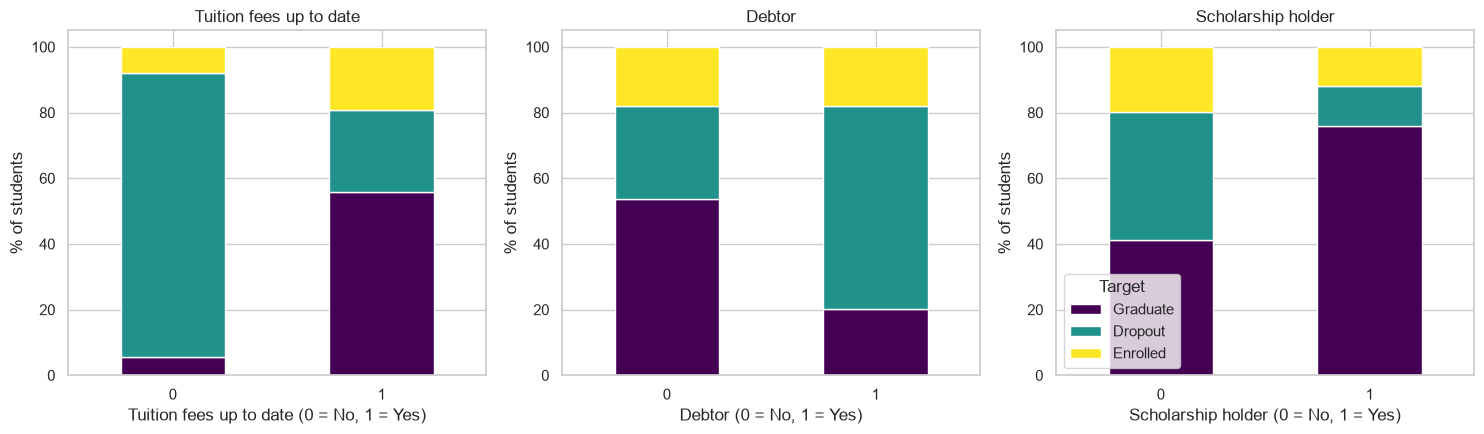

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ["Tuition fees up to date", "Debtor", "Scholarship holder"]):
    ct = pd.crosstab(df[col], df[target_col], normalize="index")[order] * 100
    ct.plot(kind="bar", stacked=True, colormap="viridis", ax=ax, legend=(ax is axes[-1]))
    ax.set_title(col)
    ax.set_ylabel("% of students")
    ax.set_xlabel(f"{col} (0 = No, 1 = Yes)")
    ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "financial_factors_vs_outcome.png", dpi=150)
plt.show()

## 5. Age at enrollment vs outcome

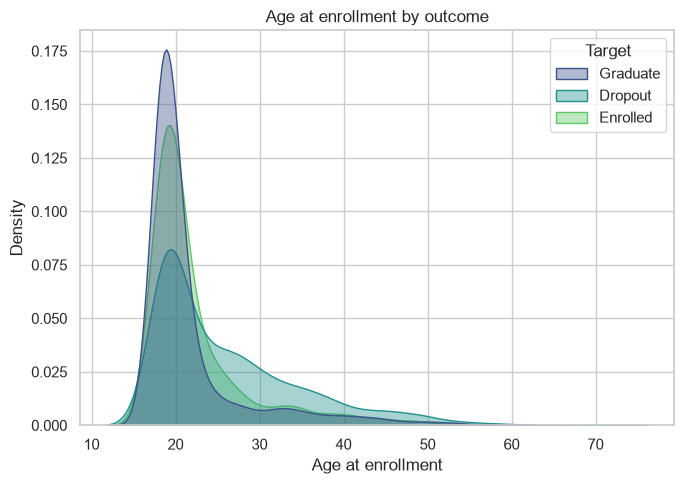

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.kdeplot(data=df, x="Age at enrollment", hue=target_col, hue_order=order, fill=True, common_norm=False, palette="viridis", alpha=0.4, ax=ax)
ax.set_title("Age at enrollment by outcome")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "age_vs_outcome.png", dpi=150)
plt.show()

## 6. Previous qualification (admission profile) vs outcome
`Previous qualification` is the closest proxy this dataset has to an
"admission grade" (the UCI/Kaggle version used here encodes it as a
categorical qualification code rather than a numeric admission score).

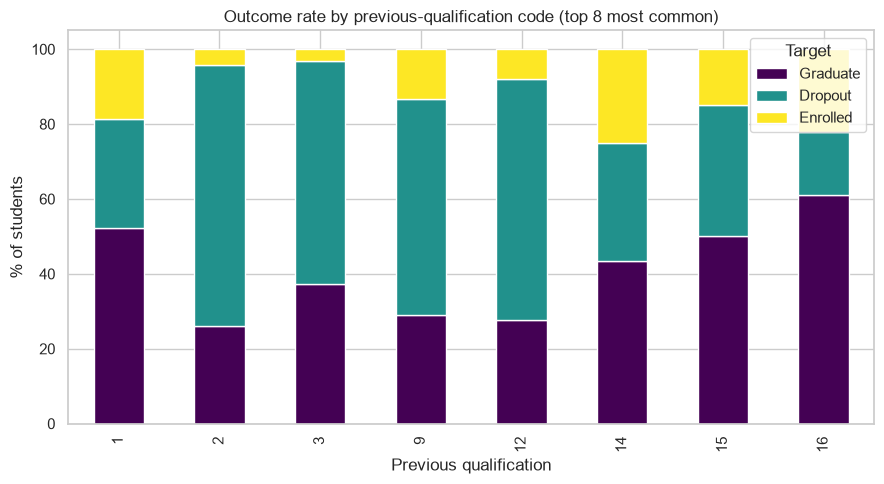

In [7]:
top_quals = df["Previous qualification"].value_counts().head(8).index
sub = df[df["Previous qualification"].isin(top_quals)]
fig, ax = plt.subplots(figsize=(9, 5))
ct = pd.crosstab(sub["Previous qualification"], sub[target_col], normalize="index")[order] * 100
ct.plot(kind="bar", stacked=True, colormap="viridis", ax=ax)
ax.set_title("Outcome rate by previous-qualification code (top 8 most common)")
ax.set_ylabel("% of students")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "previous_qualification_vs_outcome.png", dpi=150)
plt.show()

## 7. Correlation of numeric features with dropout
Quick numeric sanity check: point-biserial-style correlation between each
numeric feature and a binary `is_dropout` flag.

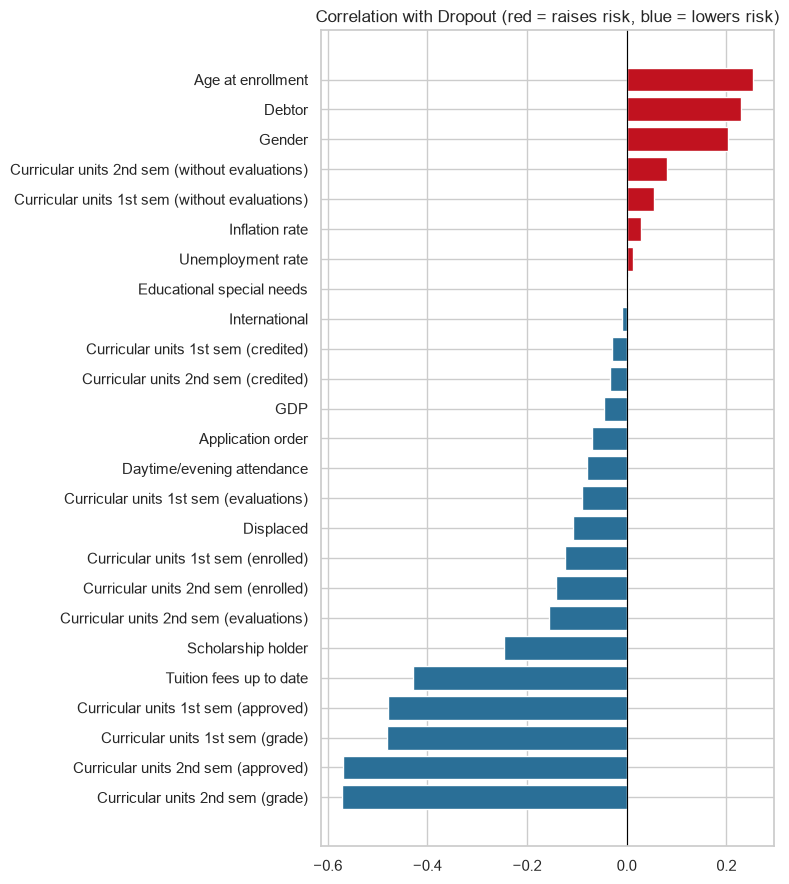

In [8]:
numeric_cols = config.BINARY_FEATURES + config.NUMERIC_FEATURES
is_dropout = (df[target_col] == "Dropout").astype(int)
corrs = df[numeric_cols].corrwith(is_dropout).sort_values()

fig, ax = plt.subplots(figsize=(8, 9))
colors = ["#c1121f" if v > 0 else "#2a6f97" for v in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlation with Dropout (red = raises risk, blue = lowers risk)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "correlation_with_dropout.png", dpi=150)
plt.show()

## Takeaways

- **In-program performance** (units approved, grades in both semesters) is
  by far the strongest and most actionable predictor — consistent with the
  SHAP-based global importance computed in `src/explain.py`.
- **Financial precarity** (tuition not up to date, debtor status, no
  scholarship) is a strong secondary signal and maps directly to a
  financial-aid intervention.
- **Age at enrollment** shows a secondary effect: older non-traditional
  students show a different risk profile than students entering directly
  from secondary school.
- These findings directly motivate the risk-band design in
  `src/intervention.py`: P(Dropout) is driven primarily by in-semester
  academic performance, which is exactly the signal advisors can act on
  *before* a student formally withdraws.